In [3]:
import numpy as np
import pandas as pd

In [4]:
df= pd.read_csv("Downloads/Business_risk_data.csv")

In [5]:


# Features & Target define karo
X = df.drop(columns=["Bankrupt?"])
y = df["Bankrupt?"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6819, 95)
y shape: (6819,)


In [6]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature importance nikaalo
importances = model.feature_importances_

# DataFrame banao
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# Importance ke basis pe sort karo
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

# Top 20 features select karo
top_features = feature_importance_df.head(20)["Feature"].tolist()

print("Top Features:\n", top_features)

# Sirf top features wala dataset
X_top = X[top_features]

print("New Shape:", X_top.shape)


Top Features:
 [" Net Income to Stockholder's Equity", ' Net Value Growth Rate', ' Persistent EPS in the Last Four Seasons', ' Borrowing dependency', ' Per Share Net profit before tax (Yuan ¥)', ' Total debt/Total net worth', ' Net Value Per Share (A)', ' Net Income to Total Assets', ' Degree of Financial Leverage (DFL)', ' Net Value Per Share (B)', ' Net profit before tax/Paid-in capital', ' Interest Coverage Ratio (Interest expense to EBIT)', ' Interest Expense Ratio', ' Non-industry income and expenditure/revenue', ' Cash/Current Liability', ' Net Value Per Share (C)', ' Liability to Equity', ' Interest-bearing debt interest rate', ' Debt ratio %', ' Continuous interest rate (after tax)']
New Shape: (6819, 20)


In [7]:
#Random Forest
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9091597796143251
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1320
           1       0.69      0.25      0.37        44

    accuracy                           0.97      1364
   macro avg       0.83      0.62      0.68      1364
weighted avg       0.97      0.97      0.97      1364



In [8]:
#XGboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:31:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost ROC-AUC: 0.9492079889807163


In [31]:
import joblib
joblib.dump(xgb, "business_risk_xgboost.pkl")

['business_risk_xgboost.pkl']

In [32]:
import os
print(os.listdir())

['fourth.ipynb', '.config', 'Music', 'scaler.pkl', 'Kaggle_competition1.ipynb', 'Vs Code Folder ', '.skiko', '.condarc', 'new human', 'Untitled1.ipynb', 'Social_Network_Ads.ipynb', 'IMG_3854.jpeg', '.DS_Store', 'Kaggle Dataset', 'nltk_data', 'Financial_Risk_management', '.CFUserTextEncoding', 'NLP_ONE_SHOT_WSCUBETECH.ipynb', 'NLP_Lab_2.ipynb', '.xonshrc', 'anaconda_projects', 'Untitled3.ipynb', 'Untitled.ipynb', '.zshrc', 'college Training', 'Hackathon_projects', 'business_risk_model.pkl', 'dataset', 'ML_Experiment_7.ipynb', '.local', 'Pictures', 'project1', 'Plant Disease Detection System', '.zprofile', 'Web Development Course ', 'tennis_training_data.csv', 'Business_app.ipynb', 'NLP_Lab_3.ipynb', 'Voice Detector project Delhi', '.zsh_history', 'Untitled2.ipynb', '.ipython', 'train (2).csv', 'Desktop', 'Library', '.matplotlib', 'PRIME(AIML) PRACTICE', 'ccc', '__pycache__', 'model.pkl', '.emulator_console_auth_token', 'NLP_Lab_1.ipynb', 'Prime(Aiml batch)', 'AI_Lab_5.ipynb', '.android'

In [13]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 133.8 kB/s  0:00:184.8 kB/s eta 0:00:02:04


In [9]:
print(y.value_counts())

Bankrupt?
0    6599
1     220
Name: count, dtype: int64


In [10]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, xgb.predict(X_test)))

[[1311    9]
 [  34   10]]


In [11]:
rf_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("Random Forest AUC:", rf_auc)
print("XGBoost AUC:", xgb_auc)

Random Forest AUC: 0.9091597796143251
XGBoost AUC: 0.9492079889807163


In [16]:
scale_pos_weight = 6599 / 220  # approx 30

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=30,
    random_state=42,
    eval_metric='logloss'
)

In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1320
           1       0.39      0.75      0.51        44

    accuracy                           0.95      1364
   macro avg       0.69      0.86      0.74      1364
weighted avg       0.97      0.95      0.96      1364



In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
from xgboost import XGBClassifier

scale_pos_weight = 6599 / 220  # imbalance handle

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [20]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9355027548209367
[[1268   52]
 [  11   33]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1320
           1       0.39      0.75      0.51        44

    accuracy                           0.95      1364
   macro avg       0.69      0.86      0.74      1364
weighted avg       0.97      0.95      0.96      1364



In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# probability already nikaal chuke ho
y_prob = xgb.predict_proba(X_test)[:,1]

# custom threshold
threshold = 0.3

y_pred_custom = (y_prob >= threshold).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

Confusion Matrix:
 [[1240   80]
 [  11   33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96      1320
           1       0.29      0.75      0.42        44

    accuracy                           0.93      1364
   macro avg       0.64      0.84      0.69      1364
weighted avg       0.97      0.93      0.95      1364



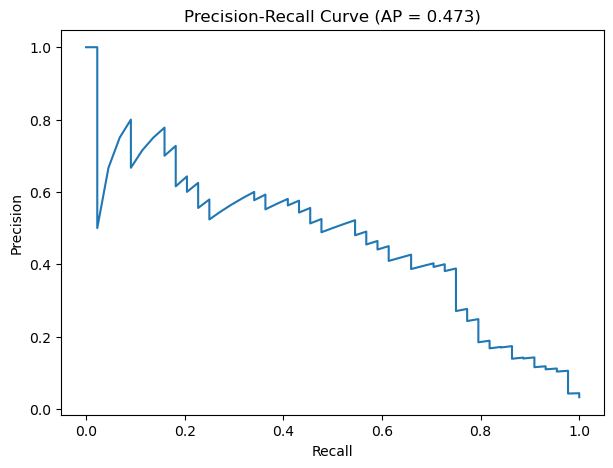

In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.3f})")
plt.show()

In [23]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 167.3 kB/s  0:00:03159.4 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


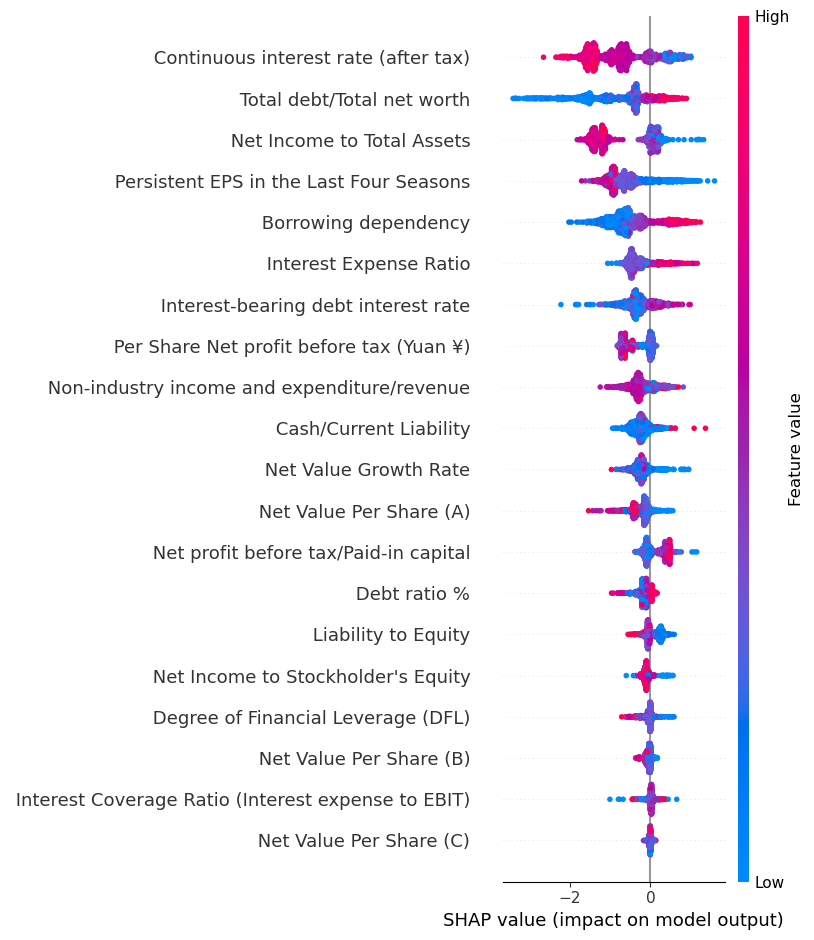

In [24]:
import shap

# SHAP explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [33]:
import joblib

joblib.dump(xgb, "business_risk_xgboost.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [34]:
model = joblib.load("business_risk_xgboost.pkl")

In [35]:
xgb

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [36]:
import os
print(os.listdir())

['fourth.ipynb', '.config', 'Music', 'scaler.pkl', 'Kaggle_competition1.ipynb', 'Vs Code Folder ', '.skiko', '.condarc', 'new human', 'Untitled1.ipynb', 'Social_Network_Ads.ipynb', 'IMG_3854.jpeg', '.DS_Store', 'Kaggle Dataset', 'nltk_data', 'Financial_Risk_management', '.CFUserTextEncoding', 'NLP_ONE_SHOT_WSCUBETECH.ipynb', 'NLP_Lab_2.ipynb', '.xonshrc', 'anaconda_projects', 'Untitled3.ipynb', 'Untitled.ipynb', '.zshrc', 'college Training', 'Hackathon_projects', 'business_risk_model.pkl', 'dataset', 'ML_Experiment_7.ipynb', '.local', 'Pictures', 'project1', 'Plant Disease Detection System', '.zprofile', 'Web Development Course ', 'tennis_training_data.csv', 'Business_app.ipynb', 'NLP_Lab_3.ipynb', 'Voice Detector project Delhi', '.zsh_history', 'Untitled2.ipynb', '.ipython', 'train (2).csv', 'Desktop', 'Library', '.matplotlib', 'PRIME(AIML) PRACTICE', 'ccc', '__pycache__', 'model.pkl', '.emulator_console_auth_token', 'NLP_Lab_1.ipynb', 'Prime(Aiml batch)', 'AI_Lab_5.ipynb', '.android'

In [37]:
import os
print(os.getcwd())

/Users/adityasingh


In [38]:
import os
print(os.getcwd())

/Users/adityasingh


In [39]:
model = joblib.load("/Users/aditya/Documents/business_risk_xgboost.pkl")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/aditya/Documents/business_risk_xgboost.pkl'